In [26]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [27]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [28]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(X_train, y_true, y_pred, title="Прогноз vs Истинные значения"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    ax1.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    ax1.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Значение')
    ax1.set_title('Тестовый период')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    ax2.plot(X_train.index, X_train.values, 
             label='Исторические (X_train)', color='green', linewidth=1.5, alpha=0.7)
    ax2.plot(y_true.index, y_true.values, 
             label='Истинные (тест)', color='blue', linewidth=1.5)
    ax2.plot(y_pred.index, y_pred.values, 
             label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Дата')
    ax2.set_ylabel('Значение')
    ax2.set_title('Полный период (история + тест)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
def show_results(model, df_train_full, df_test, target_col, exog_cols, model_path):
    last_window = df_train_full[target_col].iloc[-30:]
    y_pred = model.predict(
                steps=len(df_test),
                exog=df_test[exog_cols],
                last_window = last_window
            )

    rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
    print(f'RMSE на тесте = {rmse}')

    plot_forecast(df_train_full[target_col], df_test[target_col], y_pred)
    
def fit_best_model(df_train, best_params, target_col, exog_cols, rollings):
    best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'],
                                    window_features=rollings)
    best_model.fit(
                y=df_train[target_col],
                exog=df_train[exog_cols]
            )
    return best_model

In [29]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [30]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

rollings = RollingFeatures(
    stats=['median'],
    window_sizes=[30]
)

Глубина 0

In [31]:
depth = 0
model_path = f'../xgboost/models/xgb_v3_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [32]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, rollings=rollings)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:09:51,013] A new study created in memory with name: no-name-c1e1b69c-be62-4691-b177-cff1fe0d1149
[I 2026-05-12 17:09:51,478] Trial 0 finished with value: 3.481993869360828 and parameters: {'lags': 2, 'n_estimators': 289, 'learning_rate': 0.08910814911884596, 'max_depth': 10, 'subsample': 0.6797328170477983, 'colsample_bytree': 0.6826204439853841, 'colsample_bylevel': 0.9544801859346711, 'colsample_bynode': 0.7741861472973162, 'reg_alpha': 0.0004828910117414602, 'reg_lambda': 0.3024638621245654, 'gamma': 2.532296859680915e-05, 'min_child_weight': 2, 'max_delta_step': 1}. Best is trial 0 with value: 3.481993869360828.
[I 2026-05-12 17:09:51,783] Trial 1 finished with value: 3.500493743731508 and parameters: {'lags': 1, 'n_estimators': 713, 'learning_rate': 0.016594871253363095, 'max_depth': 3, 'subsample': 0.4032493736704054, 'colsample_bytree': 0.5826317604740354, 'colsample_bylevel': 0.5092471088543307, 'colsample_bynode': 0.49037324803770865, 'reg_alpha': 3.0135680146

Лучшие параметры = {'lags': 2, 'n_estimators': 976, 'learning_rate': 0.026748419271372795, 'max_depth': 4, 'subsample': 0.9373574805347821, 'colsample_bytree': 0.8783852056833634, 'colsample_bylevel': 0.901348125311683, 'colsample_bynode': 0.7428549265200921, 'reg_alpha': 4.819179287346103e-05, 'reg_lambda': 0.6544559341032286, 'gamma': 0.4180279475002977, 'min_child_weight': 8, 'max_delta_step': 17}
Лучший RMSE score = 3.0344980822682137


In [33]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols, rollings)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v3_0']

RMSE на тесте = 3.0350940559740467


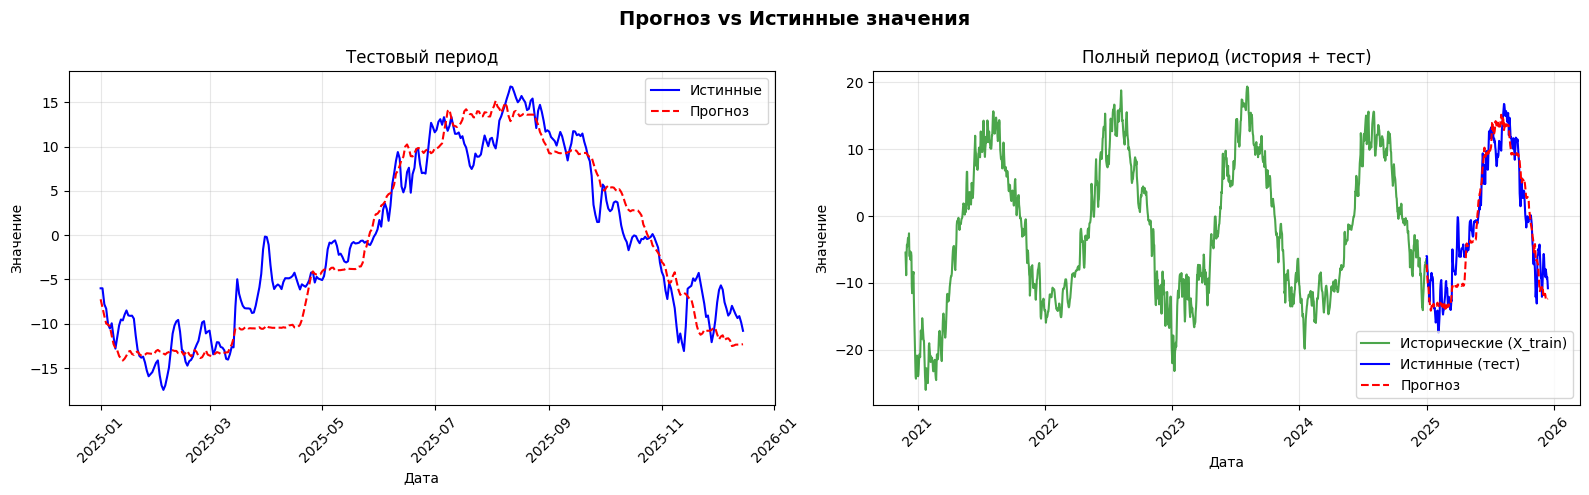

,feature,importance
4,Месяц_cos,0.428315
0,lag_1,0.257094
1,lag_2,0.182493
2,roll_median_30,0.110856
6,day_of_year_cos,0.013248
5,day_of_year_sin,0.004272
3,Месяц_sin,0.003722


In [34]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 3

In [35]:
depth = 3
model_path = f'../xgboost/models/xgb_v3_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [36]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, rollings=rollings)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:10:12,277] A new study created in memory with name: no-name-d25b3182-3d2f-418f-a491-dd2a0f344935
[I 2026-05-12 17:10:12,548] Trial 0 finished with value: 0.8187692046513521 and parameters: {'lags': 2, 'n_estimators': 456, 'learning_rate': 0.0201950534193955, 'max_depth': 9, 'subsample': 0.8101123619099209, 'colsample_bytree': 0.4497655178854113, 'colsample_bylevel': 0.8427892730333106, 'colsample_bynode': 0.959524207946894, 'reg_alpha': 0.00016581497272880825, 'reg_lambda': 1.6119428451720845e-05, 'gamma': 2.4679942720909875, 'min_child_weight': 4, 'max_delta_step': 9}. Best is trial 0 with value: 0.8187692046513521.
[I 2026-05-12 17:10:12,812] Trial 1 finished with value: 0.9669320453472765 and parameters: {'lags': 1, 'n_estimators': 353, 'learning_rate': 0.024900770564329617, 'max_depth': 5, 'subsample': 0.7001801501337379, 'colsample_bytree': 0.41441652787636757, 'colsample_bylevel': 0.8973653323050711, 'colsample_bynode': 0.9621580449488429, 'reg_alpha': 6.77179463

Лучшие параметры = {'lags': 2, 'n_estimators': 412, 'learning_rate': 0.018304876275605536, 'max_depth': 8, 'subsample': 0.6954854950635698, 'colsample_bytree': 0.7588733956881053, 'colsample_bylevel': 0.9234265815173422, 'colsample_bynode': 0.8827635759920213, 'reg_alpha': 2.7421536387390962e-05, 'reg_lambda': 1.0292803288111947, 'gamma': 0.33951081118824983, 'min_child_weight': 8, 'max_delta_step': 0}
Лучший RMSE score = 0.7570780059916556


In [37]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols, rollings)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v3_3']

RMSE на тесте = 0.9432075154556122


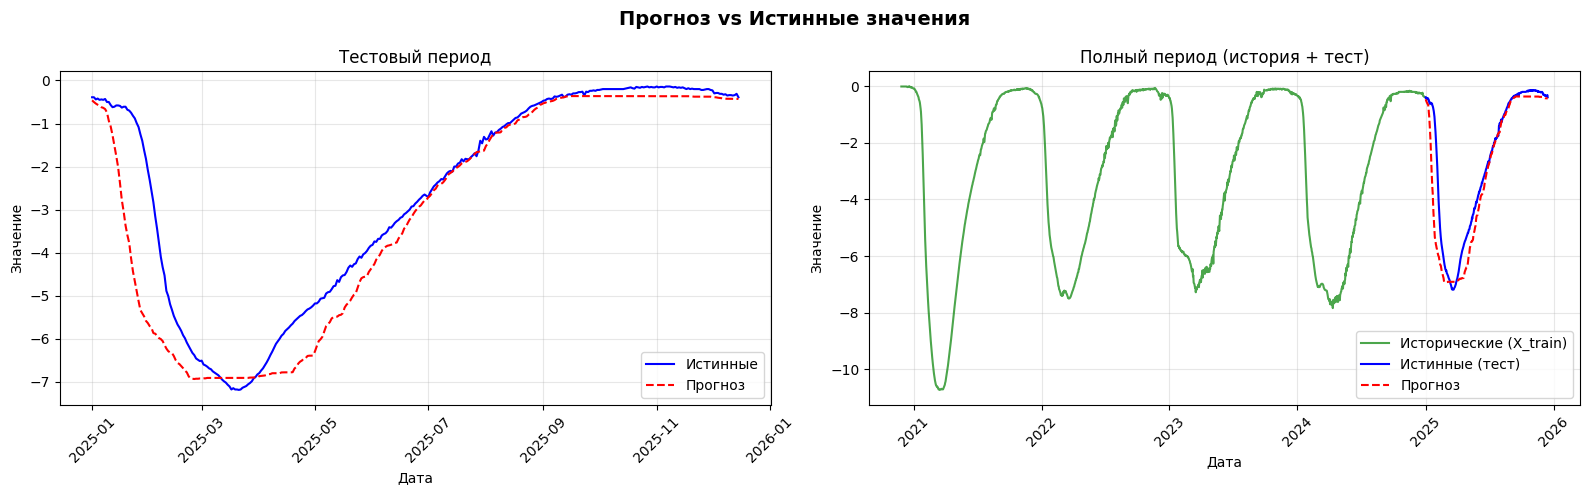

,feature,importance
3,Месяц_sin,0.316949
5,day_of_year_sin,0.267579
0,lag_1,0.166488
1,lag_2,0.148249
2,roll_median_30,0.057010
4,Месяц_cos,0.026378
6,day_of_year_cos,0.017347


In [38]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 5

In [39]:
depth = 5
model_path = f'../xgboost/models/xgb_v3_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [40]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, rollings=rollings)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:10:26,406] A new study created in memory with name: no-name-b79faeb4-39f9-424f-871f-497f111a0fcc
[I 2026-05-12 17:10:26,778] Trial 0 finished with value: 0.5922087306568469 and parameters: {'lags': 2, 'n_estimators': 952, 'learning_rate': 0.12835944678740557, 'max_depth': 9, 'subsample': 0.42715841450294334, 'colsample_bytree': 0.527331612837433, 'colsample_bylevel': 0.562747554463879, 'colsample_bynode': 0.46339496027899924, 'reg_alpha': 0.19700965659743624, 'reg_lambda': 1.3497723837088756e-05, 'gamma': 0.006156527369024698, 'min_child_weight': 14, 'max_delta_step': 16}. Best is trial 0 with value: 0.5922087306568469.
[I 2026-05-12 17:10:27,011] Trial 1 finished with value: 0.6791108750606846 and parameters: {'lags': 1, 'n_estimators': 568, 'learning_rate': 0.24168627959297806, 'max_depth': 8, 'subsample': 0.6919039423810631, 'colsample_bytree': 0.4128111890135412, 'colsample_bylevel': 0.7802799145157437, 'colsample_bynode': 0.6492132923051421, 'reg_alpha': 4.3804077

Лучшие параметры = {'lags': 1, 'n_estimators': 438, 'learning_rate': 0.1027136691621871, 'max_depth': 1, 'subsample': 0.4851940775478886, 'colsample_bytree': 0.9468190543275748, 'colsample_bylevel': 0.6987323562886796, 'colsample_bynode': 0.5003737246005634, 'reg_alpha': 0.0038532174102505895, 'reg_lambda': 0.060231515256684555, 'gamma': 1.2646709305128505, 'min_child_weight': 6, 'max_delta_step': 8}
Лучший RMSE score = 0.5300985183769314


In [41]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols, rollings)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v3_5']

RMSE на тесте = 0.7352410909564708


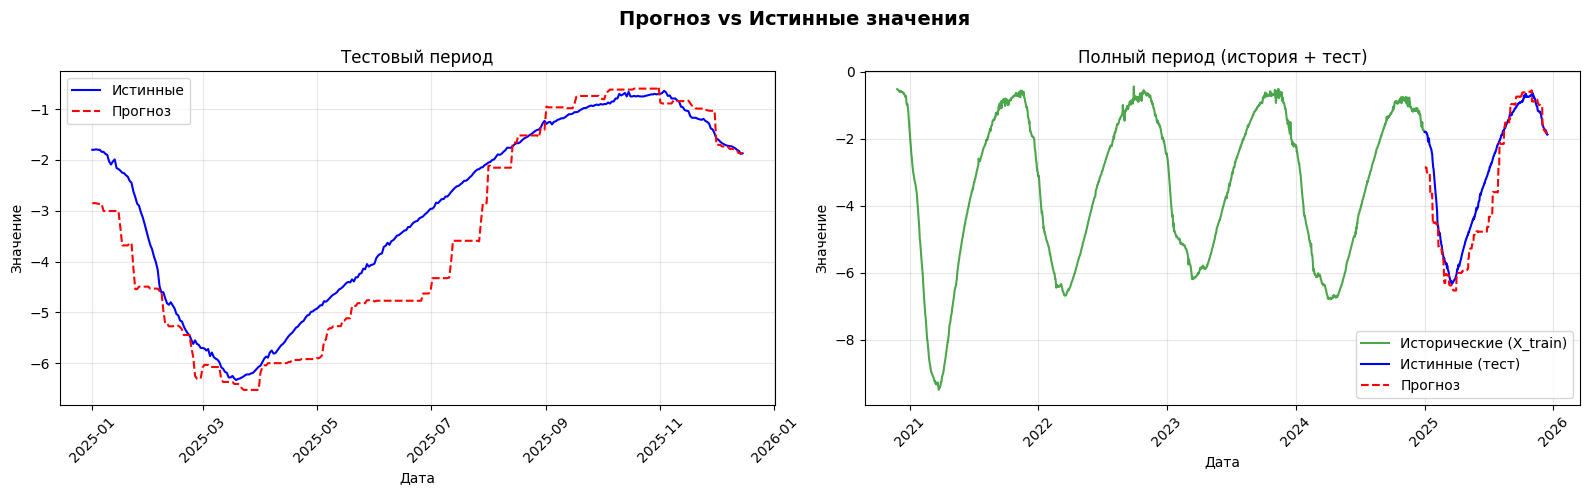

,feature,importance
0,lag_1,0.335772
1,roll_median_30,0.312196
2,Месяц_sin,0.236836
4,day_of_year_sin,0.066537
3,Месяц_cos,0.030351
5,day_of_year_cos,0.018308


In [42]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 7

In [43]:
depth = 7
model_path = f'../xgboost/models/xgb_v3_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [44]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, rollings=rollings)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:10:44,853] A new study created in memory with name: no-name-448855b2-0357-4c60-aced-4968468ac684
[I 2026-05-12 17:10:45,066] Trial 0 finished with value: 0.5934699286755263 and parameters: {'lags': 1, 'n_estimators': 243, 'learning_rate': 0.4501814462944614, 'max_depth': 1, 'subsample': 0.737466712947815, 'colsample_bytree': 0.6410321255782965, 'colsample_bylevel': 0.7527222248824582, 'colsample_bynode': 0.8705110731388168, 'reg_alpha': 1.3133669773425568e-05, 'reg_lambda': 7.666096724302658, 'gamma': 0.0005806878899233148, 'min_child_weight': 12, 'max_delta_step': 19}. Best is trial 0 with value: 0.5934699286755263.
[I 2026-05-12 17:10:45,486] Trial 1 finished with value: 0.6413997908267405 and parameters: {'lags': 1, 'n_estimators': 876, 'learning_rate': 0.0030975166100198886, 'max_depth': 7, 'subsample': 0.69580131997463, 'colsample_bytree': 0.42441631631956633, 'colsample_bylevel': 0.7677459255749821, 'colsample_bynode': 0.8499947368881129, 'reg_alpha': 3.183931296

Лучшие параметры = {'lags': 1, 'n_estimators': 804, 'learning_rate': 0.1252351949832936, 'max_depth': 7, 'subsample': 0.6110203004434486, 'colsample_bytree': 0.5043984748727033, 'colsample_bylevel': 0.8564484741157612, 'colsample_bynode': 0.46896939921263, 'reg_alpha': 0.013344012547420058, 'reg_lambda': 0.049926321088366046, 'gamma': 3.1402533553253495, 'min_child_weight': 6, 'max_delta_step': 9}
Лучший RMSE score = 0.5852102227413339


In [45]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols, rollings)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v3_7']

RMSE на тесте = 0.48413798227348476


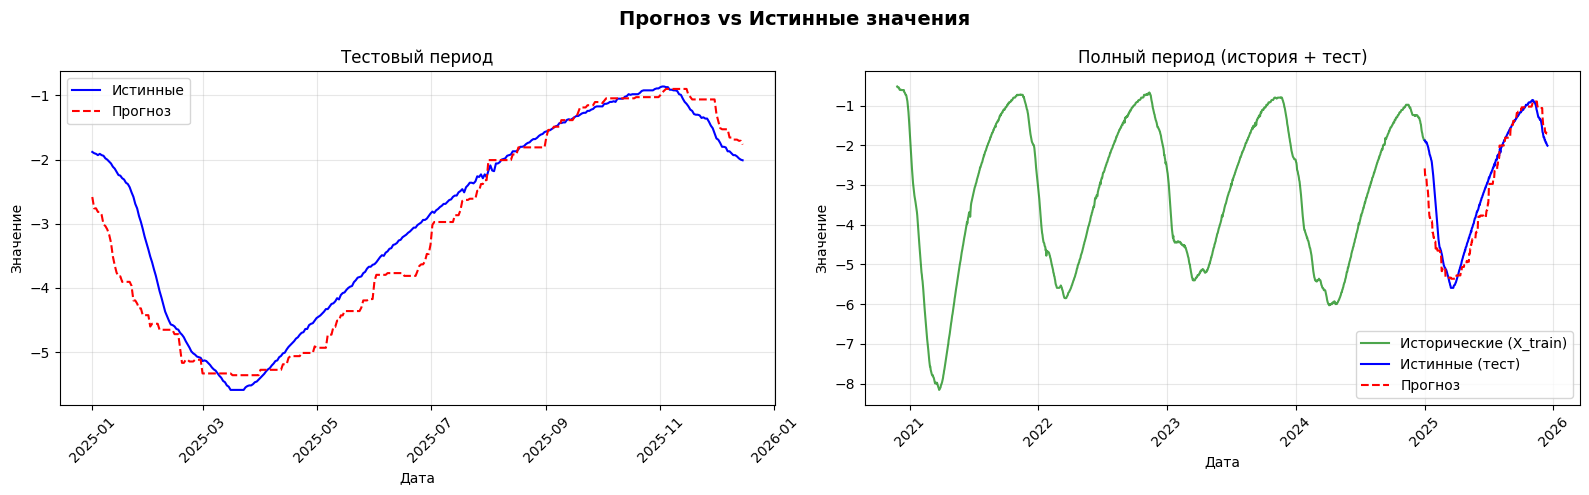

,feature,importance
4,day_of_year_sin,0.333744
2,Месяц_sin,0.279317
0,lag_1,0.166547
1,roll_median_30,0.123047
3,Месяц_cos,0.051912
5,day_of_year_cos,0.045433


In [46]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances

Глубина 10

In [47]:
depth = 10
model_path = f'../xgboost/models/xgb_v3_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [48]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, rollings=rollings)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:10:58,272] A new study created in memory with name: no-name-683dc005-2cd4-4da3-aedb-69edf3d3766c
[I 2026-05-12 17:10:58,570] Trial 0 finished with value: 0.9200728399408936 and parameters: {'lags': 1, 'n_estimators': 611, 'learning_rate': 0.0005135354095202828, 'max_depth': 1, 'subsample': 0.6709528644608143, 'colsample_bytree': 0.856570624244536, 'colsample_bylevel': 0.8928282626782447, 'colsample_bynode': 0.44044292242929994, 'reg_alpha': 0.0018951397405208444, 'reg_lambda': 0.005640219959187385, 'gamma': 0.14865430712894429, 'min_child_weight': 8, 'max_delta_step': 11}. Best is trial 0 with value: 0.9200728399408936.
[I 2026-05-12 17:10:58,754] Trial 1 finished with value: 0.4753632642813222 and parameters: {'lags': 1, 'n_estimators': 220, 'learning_rate': 0.012508666117562623, 'max_depth': 1, 'subsample': 0.9824382140947625, 'colsample_bytree': 0.838048933269196, 'colsample_bylevel': 0.7091632205014782, 'colsample_bynode': 0.4163367800396974, 'reg_alpha': 0.1531291

Лучшие параметры = {'lags': 2, 'n_estimators': 586, 'learning_rate': 0.09647369228033252, 'max_depth': 2, 'subsample': 0.5884761139753467, 'colsample_bytree': 0.9165959918924973, 'colsample_bylevel': 0.5360722812742156, 'colsample_bynode': 0.47016429796791515, 'reg_alpha': 0.5380324880093377, 'reg_lambda': 1.793461147154058, 'gamma': 1.0782957997561074e-05, 'min_child_weight': 4, 'max_delta_step': 14}
Лучший RMSE score = 0.37477119908774054


In [49]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols, rollings)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v3_10']

RMSE на тесте = 0.37937234277785403


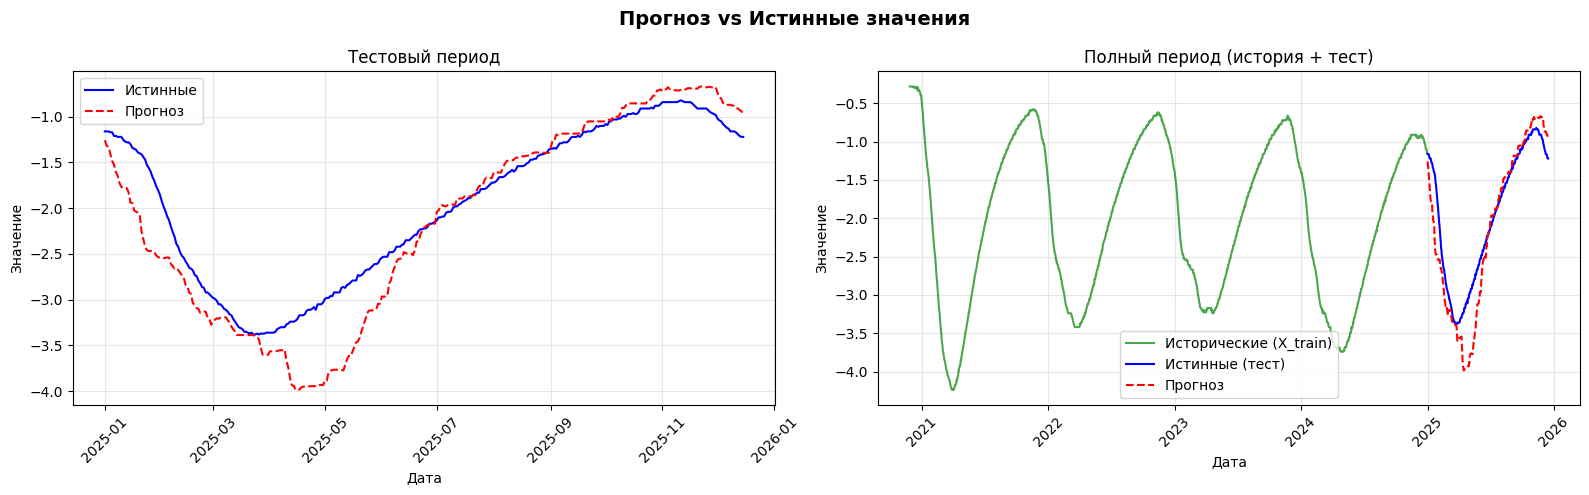

,feature,importance
5,day_of_year_sin,0.408214
2,roll_median_30,0.211746
1,lag_2,0.176395
0,lag_1,0.102261
3,Месяц_sin,0.074842
4,Месяц_cos,0.014873
6,day_of_year_cos,0.011669


In [50]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols, model_path)
importances = model.get_feature_importances()
importances